# Feature extraction: interface metrics (for multiple distance cutoffs)
* Confidence of interface prediciton (ipLDDT)
* Number of interface residues (avg across 5 models)
* Variance in the number of predicted interface residues (across 5 models)

## 1. RNase-independent proteins (positive, 22)


### a) Metrics per model

In [1]:
import os
import pandas as pd
from Bio.PDB import PDBParser
from find_interface import find_interaction_surface

def calculate_mean_interface_plddt_new(pdb_file, residue_indexes):
    """Calculate the mean pLDDT for interface residues.

    Args:
        pdb_file (str): Path to the PDB file.
        residue_indexes (list): List of residue indexes.

    Returns:
        float: Mean pLDDT value for the interface residues.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    b_factors = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[1] in residue_indexes:  # Check if residue index matches
                    for atom in residue:
                        b_factors.append(atom.bfactor)

    if not b_factors:
        return None  # Return None instead of raising an error

    return sum(b_factors) / len(b_factors)

# Main processing script
folder_path = '/mnt/storage/ana01/results/afm_10_RNase_22_copy'
rows_final = {}

cutoff_distances = [4, 5, 6, 7, 8]  # Biologically relevant cutoff distances

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    if folder.endswith("multimer"):  #Ana's only change to Edie's version
        folder_full_path = os.path.join(folder_path, folder)
        
        for file_name in os.listdir(folder_full_path):
            if file_name.startswith('unrelaxed_') and file_name.endswith('.pdb'):
                result_file = os.path.join(folder_full_path, file_name)
                
                # Extract model name from the filename
                base_model_name = file_name.replace('unrelaxed_', '').replace('.pdb', '')

                if os.path.exists(result_file):
                    try:
                        # Store results in a dictionary
                        key = (folder, base_model_name)
                        if key not in rows_final:
                            rows_final[key] = {
                                'Target': folder,
                                'Model': base_model_name,  # Keep original format
                            }

                        # Loop through different cutoff distances
                        for cutoff in cutoff_distances:
                            # Find interface residues for the current cutoff
                            interaction_data = find_interaction_surface(result_file, cutoff)

                            # Get all interface residues across all chains
                            interface_residue_indexes = set()
                            for residues in interaction_data.values():
                                interface_residue_indexes.update(map(int, residues.keys()))

                            # Calculate interface pLDDT
                            if interface_residue_indexes:
                                mean_interface_plddt = calculate_mean_interface_plddt_new(result_file, list(interface_residue_indexes))
                                residues_in_interface = len(interface_residue_indexes)
                            else:
                                mean_interface_plddt = None
                                residues_in_interface = 0

                            # Store the values under a unique column name for each cutoff
                            rows_final[key][f'ipLDDT (cutoff {cutoff} Å)'] = mean_interface_plddt
                            rows_final[key][f'# Residues in Interface (cutoff {cutoff} Å)'] = residues_in_interface

                    except Exception as e:
                        print(f"Error processing {result_file}: {e}")

# Convert dictionary to DataFrame
df = pd.DataFrame(list(rows_final.values()))

In [2]:
df.head(10)

,Target,Model,ipLDDT (cutoff 4 Å),# Residues in Interface (cutoff 4 Å),ipLDDT (cutoff 5 Å),# Residues in Interface (cutoff 5 Å),ipLDDT (cutoff 6 Å),# Residues in Interface (cutoff 6 Å),ipLDDT (cutoff 7 Å),# Residues in Interface (cutoff 7 Å),ipLDDT (cutoff 8 Å),# Residues in Interface (cutoff 8 Å)
0,IPO7_ORF2_multimer,model_1_multimer_v3_pred_0,67.002128,157,67.106221,188,68.161384,218,68.870478,250,69.355153,273
1,IPO7_ORF2_multimer,model_4_multimer_v3_pred_0,72.871716,299,73.315357,353,73.832453,406,74.038675,444,74.494233,494
2,IPO7_ORF2_multimer,model_5_multimer_v3_pred_0,69.009132,145,70.337619,178,71.428250,232,71.825857,269,72.598064,338
3,IPO7_ORF2_multimer,model_2_multimer_v3_pred_0,63.520526,72,64.204072,98,66.927545,144,68.754368,187,69.910986,236
4,IPO7_ORF2_multimer,model_3_multimer_v3_pred_0,70.110418,251,71.501025,302,72.454514,362,73.472468,420,74.492717,490
5,TUBB_ORF2_multimer,model_1_multimer_v3_pred_0,76.438129,55,75.445097,78,76.171105,103,76.611267,125,77.045621,151
6,TUBB_ORF2_multimer,model_4_multimer_v3_pred_0,73.475132,27,74.625242,46,75.333008,67,76.563484,94,77.427367,125
7,TUBB_ORF2_multimer,model_5_multimer_v3_pred_0,79.807390,94,79.751262,115,80.114787,143,80.137380,163,80.471123,198
8,TUBB_ORF2_multimer,model_2_multimer_v3_pred_0,75.608091,87,76.423577,112,76.880292,132,77.552992,163,78.040220,190
9,TUBB_ORF2_multimer,model_3_multimer_v3_pred_0,81.160590,293,81.457718,328,81.944638,380,82.356536,422,82.503513,457


### b) Average ipLDDTs over 5 model predictions, at different cutoffs.

In [4]:
#Average ipLDDTs over 5 model predictions for each complex, at different cutoffs.

df_ipLDDT = df[['Target'] + [col for col in df.columns if col.startswith('ipLDDT')]]

df_ipLDDT_avg = (
    df_ipLDDT
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

df_ipLDDT_avg.head(10)

,Target,ipLDDT (cutoff 4 Å),ipLDDT (cutoff 5 Å),ipLDDT (cutoff 6 Å),ipLDDT (cutoff 7 Å),ipLDDT (cutoff 8 Å)
0,FKBP4_ORF2_multimer,71.658756,72.367601,72.688281,73.241136,73.498497
1,HAX1_ORF2_multimer,64.646135,65.371683,66.284036,67.025632,67.946790
2,HSP90AA1_ORF2_multimer,71.118262,71.580122,71.473199,72.302106,72.931121
3,HSP90AB1_ORF2_multimer,69.361649,70.233242,70.760232,71.516737,72.650528
4,HSPA1A_ORF2_multimer,74.738680,75.308878,75.892764,76.129916,76.640651
5,HSPA1B_ORF2_multimer,74.519744,75.141596,75.721022,75.924023,76.246729
6,HSPA8_ORF2_multimer,73.306256,73.938693,74.421358,74.735333,75.011857
7,IPO7_ORF2_multimer,68.502784,69.292859,70.560829,71.392369,72.170231
8,NAP1L1_ORF2_multimer,65.331802,66.471286,67.400800,68.791224,70.136197
9,ORF2_ORF2_multimer,70.002902,70.149637,70.970164,72.146743,72.645407


Top 3 highest scoring complexes at 4 A

In [ ]:
# Extract top 5 highest-scoring complexes based on ipLDDT at 4 Å cutoff

top5_ipLDDT_4A = (
    df_ipLDDT_avg
    .sort_values(by='ipLDDT (cutoff 4 Å)', ascending=False)
    .head(5)
)

top5_ipLDDT_4A[['Target', 'ipLDDT (cutoff 4 Å)']]

                  Target  ipLDDT (cutoff 4 Å)  ipLDDT (cutoff 5 Å)  \
13    PCNA_ORF2_multimer            80.650944            80.969513   
18    TUBB_ORF2_multimer            77.297866            77.540579   
17  TUBB4B_ORF2_multimer            76.121609            76.522487   
4   HSPA1A_ORF2_multimer            74.738680            75.308878   
5   HSPA1B_ORF2_multimer            74.519744            75.141596   

    ipLDDT (cutoff 6 Å)  ipLDDT (cutoff 7 Å)  ipLDDT (cutoff 8 Å)  
13            81.125568            81.226441            81.473124  
18            78.088766            78.644332            79.097569  
17            76.961792            77.377626            77.871696  
4             75.892764            76.129916            76.640651  
5             75.721022            75.924023            76.246729  


,Target,ipLDDT (cutoff 4 Å)
13,PCNA_ORF2_multimer,80.650944
18,TUBB_ORF2_multimer,77.297866
17,TUBB4B_ORF2_multimer,76.121609
4,HSPA1A_ORF2_multimer,74.738680
5,HSPA1B_ORF2_multimer,74.519744


### c) Average # interacting residues over 5 model predictions, at different cutoffs.

In [6]:
#Average the number of residues in the interface.

df_residues = df[['Target'] + [col for col in df.columns if col.startswith('#')]]

df_residues_avg = (
    df_residues
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

df_residues_avg.head(10)

,Target,# Residues in Interface (cutoff 4 Å),# Residues in Interface (cutoff 5 Å),# Residues in Interface (cutoff 6 Å),# Residues in Interface (cutoff 7 Å),# Residues in Interface (cutoff 8 Å)
0,FKBP4_ORF2_multimer,35.8,51.8,69.2,90.2,110.4
1,HAX1_ORF2_multimer,208.2,281.6,347.6,418.6,490.2
2,HSP90AA1_ORF2_multimer,68.6,96.0,126.0,162.6,205.6
3,HSP90AB1_ORF2_multimer,108.6,144.0,184.8,225.6,278.6
4,HSPA1A_ORF2_multimer,150.8,182.4,214.6,250.4,285.6
5,HSPA1B_ORF2_multimer,140.0,179.0,213.4,250.8,284.4
6,HSPA8_ORF2_multimer,151.4,187.8,221.6,257.0,293.0
7,IPO7_ORF2_multimer,184.8,223.8,272.4,314.0,366.2
8,NAP1L1_ORF2_multimer,154.2,208.8,266.8,332.0,396.0
9,ORF2_ORF2_multimer,46.8,66.0,87.0,110.8,134.2


### d) SD interacting residues over 5 model predictions, at different cutoffs.

In [7]:
#SD of number of resifues in the interface across 5 model predictions per cutoff

df_residues_sd = (
    df_residues
    .groupby('Target')
    .std(numeric_only=True)
    .reset_index()
    .rename(columns=lambda col: f"SD {col}" if col != "Target" else col)
)

# Normalize SD by mean (relative variability)
df_residues_sd_norm = df_residues_sd.copy()

for col in df_residues_sd.columns:
    if col != "Target":
        # match SD column to corresponding mean column
        mean_col = col.replace("SD ", "")
        df_residues_sd_norm[col] = df_residues_sd[col] / df_residues_avg[mean_col]

df_residues_sd_norm.head(10)

,Target,SD # Residues in Interface (cutoff 4 Å),SD # Residues in Interface (cutoff 5 Å),SD # Residues in Interface (cutoff 6 Å),SD # Residues in Interface (cutoff 7 Å),SD # Residues in Interface (cutoff 8 Å)
0,FKBP4_ORF2_multimer,0.931764,0.768136,0.611598,0.559587,0.509449
1,HAX1_ORF2_multimer,0.036484,0.044183,0.044828,0.037339,0.039594
2,HSP90AA1_ORF2_multimer,0.224082,0.292038,0.322529,0.298471,0.288867
3,HSP90AB1_ORF2_multimer,0.293982,0.263843,0.240707,0.252593,0.225540
4,HSPA1A_ORF2_multimer,0.503704,0.445069,0.384197,0.345725,0.329761
5,HSPA1B_ORF2_multimer,0.528789,0.422130,0.363653,0.319258,0.294159
6,HSPA8_ORF2_multimer,0.570973,0.497926,0.436358,0.392041,0.347327
7,IPO7_ORF2_multimer,0.487800,0.457932,0.397745,0.357434,0.329089
8,NAP1L1_ORF2_multimer,0.262882,0.236048,0.233596,0.199444,0.166475
9,ORF2_ORF2_multimer,0.542752,0.409792,0.345689,0.313256,0.320565


### e) Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_RNase

In [8]:
#Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_RNase
df_ipLDDT_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_RNase/ipLDDT_avg_pos.csv', index=False)
df_residues_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_avg_pos.csv', index=False)
df_residues_sd_norm.to_csv('/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_sd_pos.csv', index=False)

## 2. RNase-dependent proteins (negative, 12)

### a)

In [9]:
import os
import pandas as pd
from Bio.PDB import PDBParser
from find_interface import find_interaction_surface

def calculate_mean_interface_plddt_new(pdb_file, residue_indexes):
    """Calculate the mean pLDDT for interface residues.

    Args:
        pdb_file (str): Path to the PDB file.
        residue_indexes (list): List of residue indexes.

    Returns:
        float: Mean pLDDT value for the interface residues.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    b_factors = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[1] in residue_indexes:  # Check if residue index matches
                    for atom in residue:
                        b_factors.append(atom.bfactor)

    if not b_factors:
        return None  # Return None instead of raising an error

    return sum(b_factors) / len(b_factors)

# Main processing script
folder_path = '/mnt/storage/ana01/results/afm_11_RNase_13_no_MOV10_copy'
rows_final = {}

cutoff_distances = [2, 3, 4, 5, 6, 7, 8]  # Different cutoff distances; custom = adding 2 and 3

for folder in os.listdir(folder_path):
    if folder == '.DS_Store':
        continue
    if folder.endswith("multimer"):   #Ana's only change to Edie's version
        folder_full_path = os.path.join(folder_path, folder)
        
        for file_name in os.listdir(folder_full_path):
            if file_name.startswith('unrelaxed_') and file_name.endswith('.pdb'):
                result_file = os.path.join(folder_full_path, file_name)
                
                # Extract model name from the filename
                base_model_name = file_name.replace('unrelaxed_', '').replace('.pdb', '')

                if os.path.exists(result_file):
                    try:
                        # Store results in a dictionary
                        key = (folder, base_model_name)
                        if key not in rows_final:
                            rows_final[key] = {
                                'Target': folder,
                                'Model': base_model_name,  # Keep original format
                            }

                        # Loop through different cutoff distances
                        for cutoff in cutoff_distances:
                            # Find interface residues for the current cutoff
                            interaction_data = find_interaction_surface(result_file, cutoff)

                            # Get all interface residues across all chains
                            interface_residue_indexes = set()
                            for residues in interaction_data.values():
                                interface_residue_indexes.update(map(int, residues.keys()))

                            # Calculate interface pLDDT
                            if interface_residue_indexes:
                                mean_interface_plddt = calculate_mean_interface_plddt_new(result_file, list(interface_residue_indexes))
                                residues_in_interface = len(interface_residue_indexes)
                            else:
                                mean_interface_plddt = None
                                residues_in_interface = 0

                            # Store the values under a unique column name for each cutoff
                            rows_final[key][f'ipLDDT (cutoff {cutoff} Å)'] = mean_interface_plddt
                            rows_final[key][f'# Residues in Interface (cutoff {cutoff} Å)'] = residues_in_interface

                    except Exception as e:
                        print(f"Error processing {result_file}: {e}")

# Convert dictionary to DataFrame
df = pd.DataFrame(list(rows_final.values()))

In [10]:
df.head(10)

,Target,Model,ipLDDT (cutoff 2 Å),# Residues in Interface (cutoff 2 Å),ipLDDT (cutoff 3 Å),# Residues in Interface (cutoff 3 Å),ipLDDT (cutoff 4 Å),# Residues in Interface (cutoff 4 Å),ipLDDT (cutoff 5 Å),# Residues in Interface (cutoff 5 Å),ipLDDT (cutoff 6 Å),# Residues in Interface (cutoff 6 Å),ipLDDT (cutoff 7 Å),# Residues in Interface (cutoff 7 Å),ipLDDT (cutoff 8 Å),# Residues in Interface (cutoff 8 Å)
0,RPLP0P6_ORF2_multimer,model_1_multimer_v3_pred_0,58.058870,46,60.029410,81,62.134871,123,63.930510,164,65.527143,200,67.664430,242,69.790966,302
1,RPLP0P6_ORF2_multimer,model_4_multimer_v3_pred_0,63.879007,34,62.924606,42,64.722836,74,66.346938,98,67.996749,124,69.961319,162,70.564702,191
2,RPLP0P6_ORF2_multimer,model_5_multimer_v3_pred_0,65.967513,25,66.699625,49,68.678010,75,71.383707,113,71.201263,140,71.163702,179,71.985026,228
3,RPLP0P6_ORF2_multimer,model_2_multimer_v3_pred_0,NaN,0,58.265313,2,67.919128,24,69.997035,39,69.303277,56,70.796023,79,71.220876,116
4,RPLP0P6_ORF2_multimer,model_3_multimer_v3_pred_0,61.004091,21,64.718833,35,64.834063,58,66.134457,85,67.692637,108,69.056336,139,70.519613,170
5,ZCCHC3_ORF2_multimer,model_1_multimer_v3_pred_0,67.908645,30,67.345417,54,68.339693,85,69.840955,128,70.046736,175,70.089974,215,71.270992,266
6,ZCCHC3_ORF2_multimer,model_4_multimer_v3_pred_0,66.371472,16,66.881657,29,70.343139,52,68.760216,74,71.308346,120,72.408455,153,73.112599,191
7,ZCCHC3_ORF2_multimer,model_5_multimer_v3_pred_0,62.248916,25,61.950496,42,63.440855,72,65.731467,105,67.695560,154,68.357943,208,69.622111,287
8,ZCCHC3_ORF2_multimer,model_2_multimer_v3_pred_0,61.884543,23,63.799598,36,63.717072,48,64.108727,62,64.660395,84,65.763585,104,66.654530,131
9,ZCCHC3_ORF2_multimer,model_3_multimer_v3_pred_0,65.823388,36,67.190787,68,67.083866,104,67.859324,152,69.423350,211,70.005126,255,71.750651,319


### b) c) d) e)

In [12]:
#Average ipLDDTs over 5 model predictions for each complex, at different cutoffs.

df_ipLDDT = df[['Target'] + [col for col in df.columns if col.startswith('ipLDDT')]]

df_ipLDDT_avg = (
    df_ipLDDT
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

#Average the number of residues in the interface.

df_residues = df[['Target'] + [col for col in df.columns if col.startswith('#')]]

df_residues_avg = (
    df_residues
    .groupby('Target')
    .mean(numeric_only=True)
    .reset_index()
)

#SD of number of resifues in the interface across 5 model predictions per cutoff

df_residues_sd = (
    df_residues
    .groupby('Target')
    .std(numeric_only=True)
    .reset_index()
    .rename(columns=lambda col: f"SD {col}" if col != "Target" else col)
)

# Normalize SD by mean (relative variability)
df_residues_sd_norm = df_residues_sd.copy()

for col in df_residues_sd.columns:
    if col != "Target":
        # match SD column to corresponding mean column
        mean_col = col.replace("SD ", "")
        df_residues_sd_norm[col] = df_residues_sd[col] / df_residues_avg[mean_col]

#Export all three DataFrames to /mnt/storage/ana01/results/Interface_metrics_RNase
df_ipLDDT_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_RNase/ipLDDT_avg_neg.csv', index=False)
df_residues_avg.to_csv('/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_avg_neg.csv', index=False)
df_residues_sd_norm.to_csv('/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_sd_neg.csv', index=False)


In [ ]:
# Extract top 5 highest-scoring complexes based on ipLDDT at 4 Å cutoff

top5_ipLDDT_4A = (
    df_ipLDDT_avg
    .sort_values(by='ipLDDT (cutoff 4 Å)', ascending=False)
    .head(5)
)

top5_ipLDDT_4A[['Target', 'ipLDDT (cutoff 4 Å)']]

                 Target  ipLDDT (cutoff 2 Å)  ipLDDT (cutoff 3 Å)  \
0  EIF4A3_ORF2_multimer            71.960212            71.660708   
4  RPL10A_ORF2_multimer            70.792702            70.832272   
6   RPL30_ORF2_multimer            71.561536            70.968352   
5   RPL12_ORF2_multimer            70.414365            71.003592   
1   MAGOH_ORF2_multimer            70.749041            70.526764   

   ipLDDT (cutoff 4 Å)  ipLDDT (cutoff 5 Å)  ipLDDT (cutoff 6 Å)  \
0            72.829215            73.879873            74.575771   
4            72.329859            73.309762            73.591011   
6            71.966677            71.876371            72.362213   
5            71.261131            71.645801            72.300983   
1            70.944455            72.256985            73.118348   

   ipLDDT (cutoff 7 Å)  ipLDDT (cutoff 8 Å)  
0            75.282733            75.739652  
4            74.135613            74.544615  
6            72.373811            72.7

,Target,ipLDDT (cutoff 4 Å)
0,EIF4A3_ORF2_multimer,72.829215
4,RPL10A_ORF2_multimer,72.329859
6,RPL30_ORF2_multimer,71.966677
5,RPL12_ORF2_multimer,71.261131
1,MAGOH_ORF2_multimer,70.944455


## 3. STATISTICAL TESTING (MWU) AND VISUALIZATION

### a) avg_ipLDDT per cutoff

One-sided MWU test for each cutoff:

H₀: distributions are equal

H₁: ipLDDT (pos) > ipLDDT (neg)

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_pos = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_RNase/ipLDDT_avg_pos.csv")
df_neg = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_RNase/ipLDDT_avg_neg.csv")

sns.set(style="darkgrid", context="paper")

In [15]:
from scipy.stats import mannwhitneyu
import pandas as pd


results = []

iplddt_cols = [col for col in df_pos.columns if col.startswith("ipLDDT")]

for col in iplddt_cols:
    
    # Perform one-sided Mann–Whitney U test
    U, p = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"   # H1: pos > neg
    )
    
    results.append({
        "Cutoff": col,
        "U_statistic": U,
        "p_value": p
    })

# Convert to DataFrame
df_mwu_results = pd.DataFrame(results)

df_mwu_results["significance"] = pd.cut(
    df_mwu_results["p_value"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)


#correction for multiple testing using Benjamini-Hochberg FDR
from statsmodels.stats.multitest import multipletests

reject, p_adj, _, _ = multipletests(
    df_mwu_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df_mwu_results["p_adj"] = p_adj
df_mwu_results["reject_H0"] = reject

df_mwu_results["significance_adj"] = pd.cut(
    df_mwu_results["p_adj"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

df_mwu_results



,Cutoff,U_statistic,p_value,significance,p_adj,reject_H0,significance_adj
0,ipLDDT (cutoff 4 Å),191.0,0.052442,ns,0.173908,False,ns
1,ipLDDT (cutoff 5 Å),183.0,0.088748,ns,0.173908,False,ns
2,ipLDDT (cutoff 6 Å),176.0,0.133600,ns,0.173908,False,ns
3,ipLDDT (cutoff 7 Å),171.0,0.173908,ns,0.173908,False,ns
4,ipLDDT (cutoff 8 Å),171.0,0.173908,ns,0.173908,False,ns


Plots (Figure 12 A and A1)

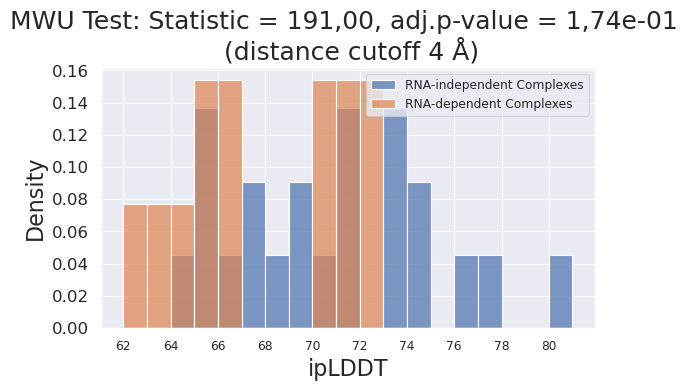

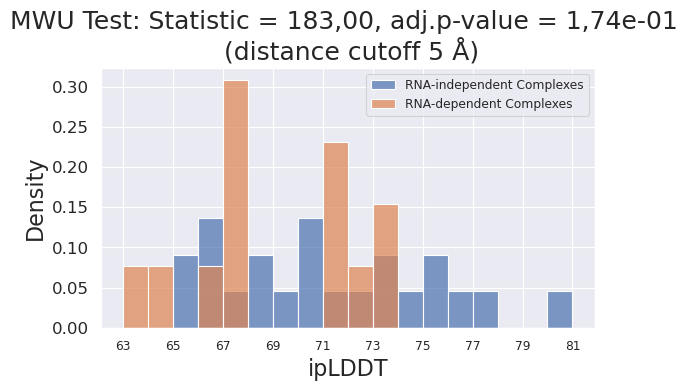

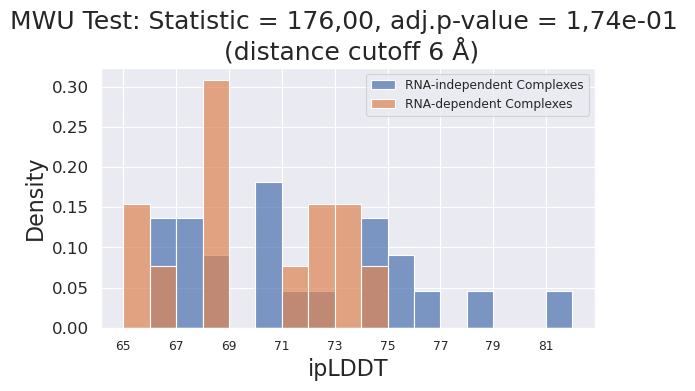

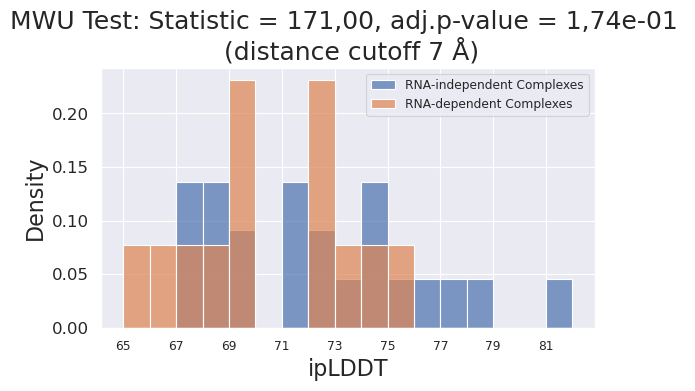

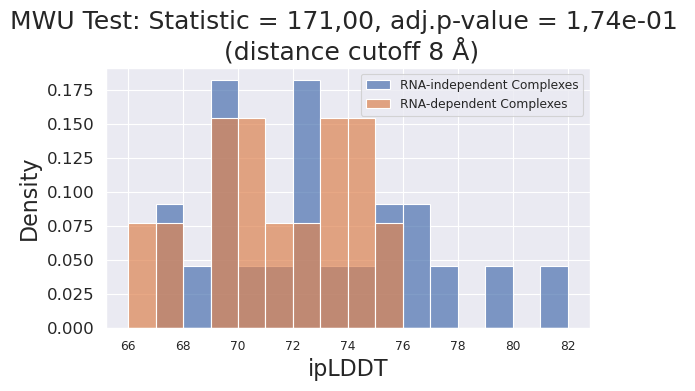

In [16]:
import numpy as np

for col in iplddt_cols:
    plt.figure(figsize=(6, 4))
    
    combined = pd.concat([df_pos[col], df_neg[col]])
    
    bin_width = 1
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-independent Complexes",
    )
    
    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-dependent Complexes",
    )
    
    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    U_stat = row["U_statistic"]
    p_val = row["p_adj"] # Use adjusted p-value 

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

   
    title = f"MWU Test: Statistic = {U_stat:.2f}, adj.p-value = {p_val:.2e} \n (distance cutoff {cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")  

    plt.title(title, fontsize=18)
    plt.xlabel("ipLDDT", fontsize=16)
    plt.ylabel("Density", fontsize=16)

    ticks = np.arange(np.floor(min_edge), np.ceil(max_edge) + 1, 2)
    labels = ["0" if abs(x) < 1e-9 else str(int(x)) for x in ticks]

    plt.xticks(ticks, labels)
    plt.yticks(fontsize=12)

    plt.legend()
    
    plt.tight_layout()
    plt.savefig(
        f"/mnt/storage/ana01/results/figures/RNase/hist_{col.replace(' ', '_').replace('Å','A')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.close()

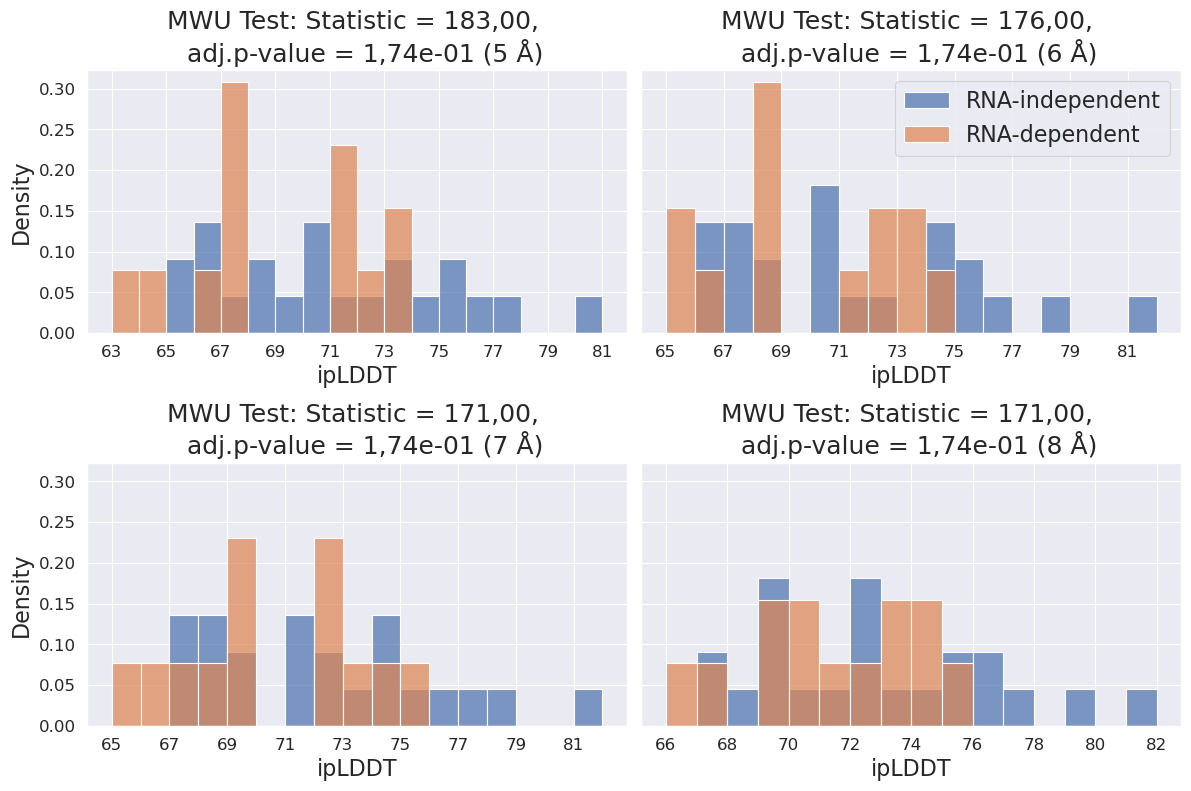

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


iplddt_cols = sorted(
    [col for col in iplddt_cols if any(k in col for k in ["5", "6", "7", "8"])],
    key=lambda x: float("".join(c for c in x if (c.isdigit() or c == ".")))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, iplddt_cols):

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 1
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-independent",
        ax=ax
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-dependent",
        ax=ax
    )

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    U_stat = row["U_statistic"]
    p_val = row["p_adj"]

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

    title = f"MWU Test: Statistic = {U_stat:.2f}, \n  adj.p-value = {p_val:.2e} ({cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("ipLDDT", fontsize=16)
    ax.set_ylabel("Density", fontsize=16)

    ticks = np.arange(np.floor(min_edge), np.ceil(max_edge) + 1, 2)
    labels = ["0" if abs(x) < 1e-9 else str(int(x)) for x in ticks]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.tick_params(axis='both', labelsize=12)

    
axes[1].legend(fontsize=16, loc="upper right")

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/RNase/ipLDDT_2x2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Plot for Figure 12 B

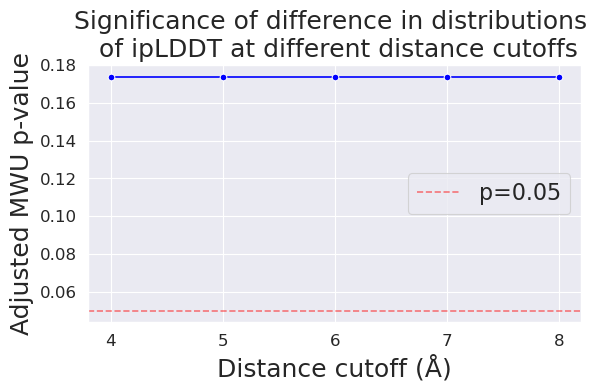

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", context="paper")

df_plot = df_mwu_results.copy()
df_plot['Cutoff_Å'] = df_plot['Cutoff'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_plot,
    x='Cutoff_Å',
    y='p_adj',
    marker='o',
    color='blue'
)

plt.axhline(0.05, linestyle='--', color='red', alpha=0.5, label='p=0.05')

plt.xlabel("Distance cutoff (Å)", fontsize=18)
plt.ylabel("Adjusted MWU p-value", fontsize=18)
plt.title("Significance of difference in distributions \n of ipLDDT at different distance cutoffs", fontsize=18)

plt.xticks(df_plot['Cutoff_Å'], fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=16)

plt.tight_layout()
plt.show()

### b) Number of interface residues per cutoff

MWU one-sided

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_pos = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_avg_pos.csv")
df_neg = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_avg_neg.csv")

# Seaborn style
sns.set(style="darkgrid", context="paper")

In [20]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

num_res_cols = [col for col in df_pos.columns if col.startswith("#")]
results = []

for col in num_res_cols:

    # Perform one-sided Mann–Whitney U test
    U, p = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"   # H1: pos > neg
    )

    results.append({
        "Cutoff": col,
        "U_statistic": U,
        "p_value": p
    })

# Convert to DataFrame
df_mwu_results = pd.DataFrame(results)

# Raw p-value significance
df_mwu_results["significance"] = pd.cut(
    df_mwu_results["p_value"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

# Benjamini–Hochberg FDR correction
reject, p_adj, _, _ = multipletests(
    df_mwu_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df_mwu_results["p_adj"] = p_adj
df_mwu_results["reject_H0"] = reject

# Adjusted p-value significance
df_mwu_results["significance_adj"] = pd.cut(
    df_mwu_results["p_adj"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

df_mwu_results

,Cutoff,U_statistic,p_value,significance,p_adj,reject_H0,significance_adj
0,# Residues in Interface (cutoff 4 Å),188.5,0.062222,ns,0.182813,False,ns
1,# Residues in Interface (cutoff 5 Å),173.0,0.156940,ns,0.182813,False,ns
2,# Residues in Interface (cutoff 6 Å),175.0,0.141066,ns,0.182813,False,ns
3,# Residues in Interface (cutoff 7 Å),174.0,0.148879,ns,0.182813,False,ns
4,# Residues in Interface (cutoff 8 Å),170.0,0.182813,ns,0.182813,False,ns


Histograms (Figure 13 A and A2)

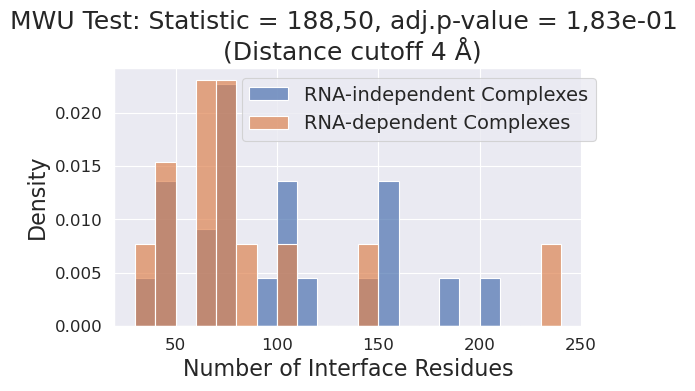

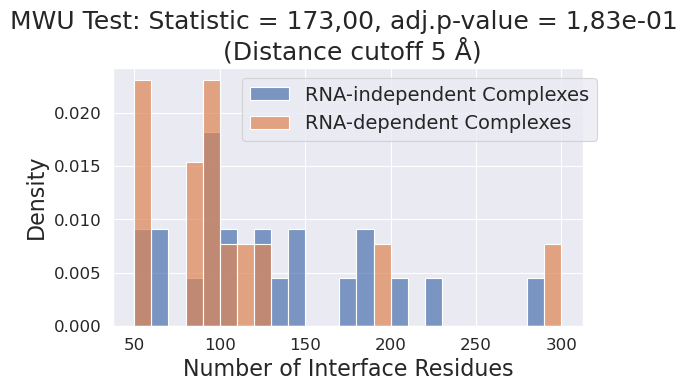

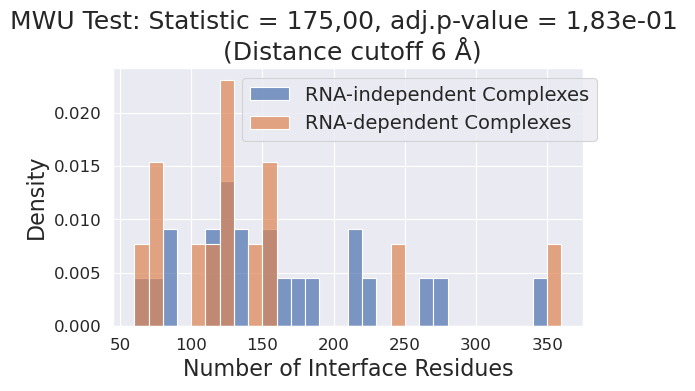

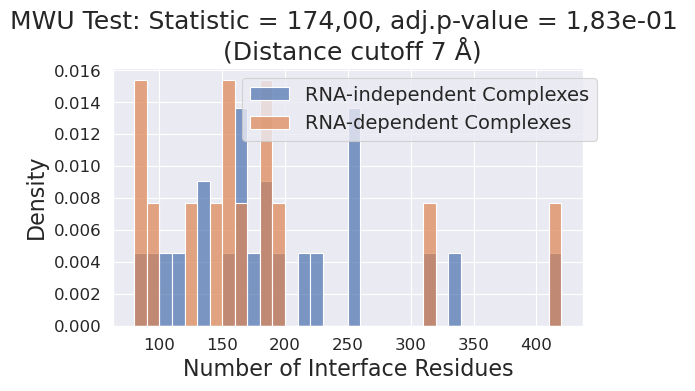

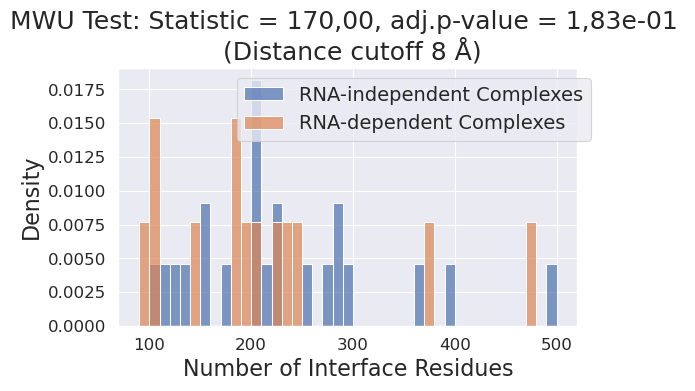

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

num_res_cols = [col for col in df_pos.columns if col.startswith("#")]

for col in num_res_cols:

    U_stat, p_value = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"
    )

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]

    combined = pd.concat([df_pos[col], df_neg[col]])
    bin_width = 10
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-independent Complexes",
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-dependent Complexes",
    )

    title = f"MWU Test: Statistic = {U_stat:.2f}, adj.p-value = {p_adj:.2e} \n (Distance cutoff {cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    plt.title(title, fontsize=18)

    plt.xlabel("Number of Interface Residues", fontsize=16)
    plt.ylabel("Density", fontsize=16)
    plt.legend(fontsize=14, loc="upper right", bbox_to_anchor=(1.05, 1))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(
        f"/mnt/storage/ana01/results/figures/RNase/hist_{col.replace(' ', '_').replace('Å','A')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

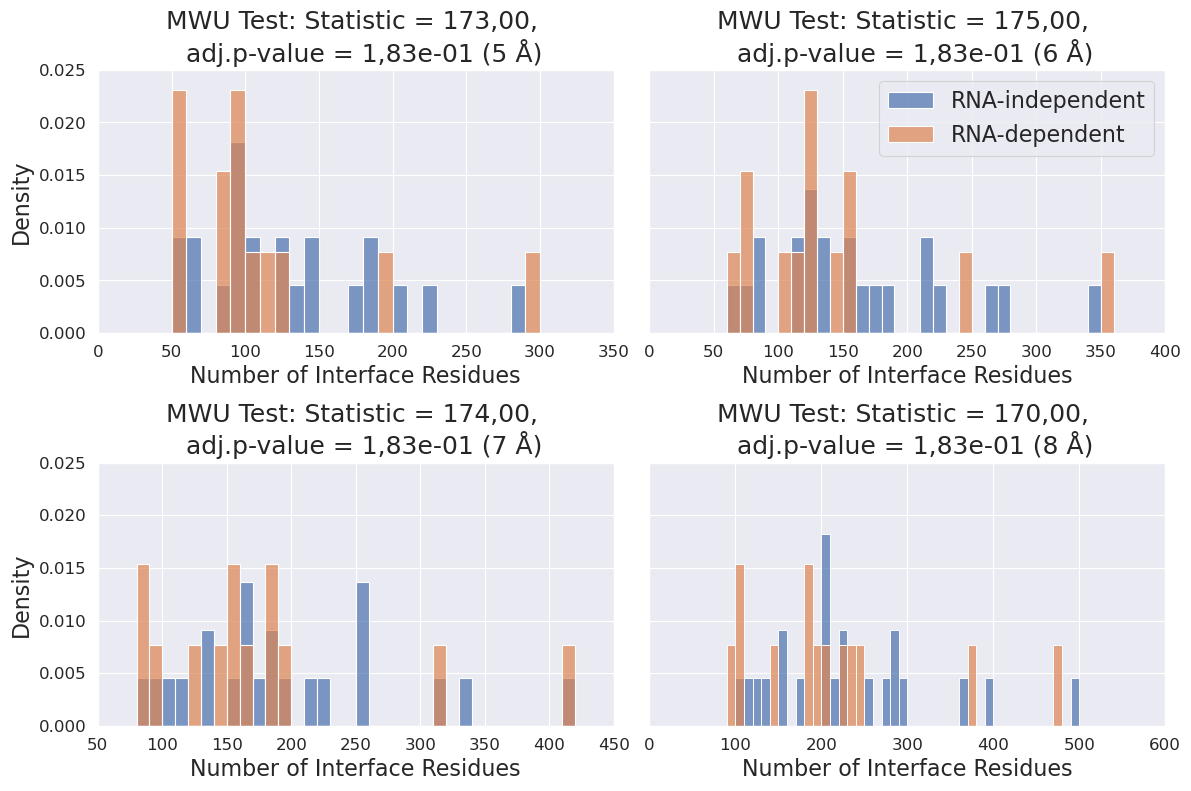

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_res_cols = sorted(
    [col for col in num_res_cols if any(k in col for k in ["5", "6", "7", "8"])],
    key=lambda x: float("".join(c for c in x if (c.isdigit() or c == ".")))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, num_res_cols):

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]

    combined = pd.concat([df_pos[col], df_neg[col]])
    bin_width = 10
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-independent",
        ax=ax
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-dependent",
        ax=ax
    )

    U_stat, _ = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"
    )

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

    title = f"MWU Test: Statistic = {U_stat:.2f}, \n  adj.p-value = {p_adj:.2e} ({cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    ax.set_title(title, fontsize=18)

    ax.set_xlabel("Number of Interface Residues", fontsize=16)
    ax.set_ylabel("Density", fontsize=16)

    ax.tick_params(axis='both', labelsize=12)

    ax.set_xticks(ax.get_xticks())
    ax.set_yticks(ax.get_yticks())


axes[1].legend(fontsize=16, loc="upper right")

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/RNase/interface_residues_2x2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Plot for Figure 13 B

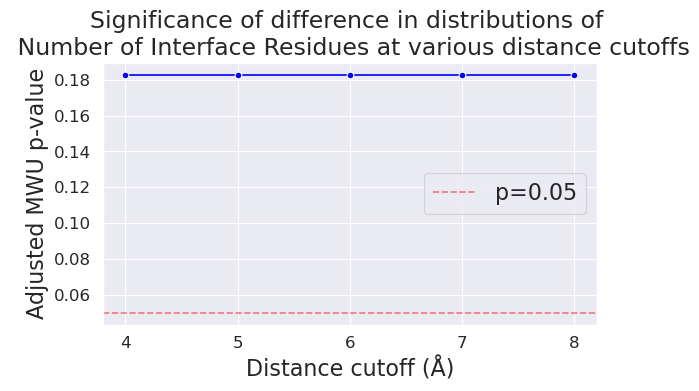

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style
sns.set(style="darkgrid", context="paper")

# Make a copy for plotting
df_plot = df_mwu_results.copy()

# Cutoff labels to numbers for nicer x-axis
df_plot['Cutoff_Å'] = df_plot['Cutoff'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_plot,
    x='Cutoff_Å',
    y='p_adj',
    marker='o',
    color='blue'
)

# Horizontal line for significance threshold
plt.axhline(0.05, linestyle='--', color='red', alpha=0.5, label='p=0.05')

plt.xlabel("Distance cutoff (Å)", fontsize=16)
plt.ylabel("Adjusted MWU p-value", fontsize=16)
plt.title("Significance of difference in distributions of \n Number of Interface Residues at various distance cutoffs", fontsize=17)
plt.xticks(df_plot['Cutoff_Å'], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize = 16)
plt.tight_layout()
plt.show()

### c) SD in number of residues per cutoff

MWU one-sided

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_pos = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_sd_pos.csv")
df_neg = pd.read_csv("/mnt/storage/ana01/results/Interface_metrics_RNase/num_residues_sd_neg.csv")

# Seaborn style
sns.set(style="darkgrid", context="paper")

In [25]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

sd_res_cols = [col for col in df_pos.columns if col.startswith("SD")]
results = []

for col in sd_res_cols:

    U, p = mannwhitneyu(
        df_pos[col],
        df_neg[col],
        alternative="greater"
    )

    results.append({
        "Cutoff": col,
        "U_statistic": U,
        "p_value": p
    })

df_mwu_results = pd.DataFrame(results)

df_mwu_results["significance"] = pd.cut(
    df_mwu_results["p_value"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

reject, p_adj, _, _ = multipletests(
    df_mwu_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df_mwu_results["p_adj"] = p_adj
df_mwu_results["reject_H0"] = reject

df_mwu_results["significance_adj"] = pd.cut(
    df_mwu_results["p_adj"],
    bins=[-1, 0.001, 0.01, 0.05, 1],
    labels=["***", "**", "*", "ns"]
)

df_mwu_results

,Cutoff,U_statistic,p_value,significance,p_adj,reject_H0,significance_adj
0,SD # Residues in Interface (cutoff 4 Å),127.0,0.713385,ns,0.713385,False,ns
1,SD # Residues in Interface (cutoff 5 Å),129.0,0.689708,ns,0.713385,False,ns
2,SD # Residues in Interface (cutoff 6 Å),134.0,0.627154,ns,0.713385,False,ns
3,SD # Residues in Interface (cutoff 7 Å),146.0,0.465992,ns,0.713385,False,ns
4,SD # Residues in Interface (cutoff 8 Å),154.0,0.359998,ns,0.713385,False,ns


Histograms (Figure 14A and A3) 

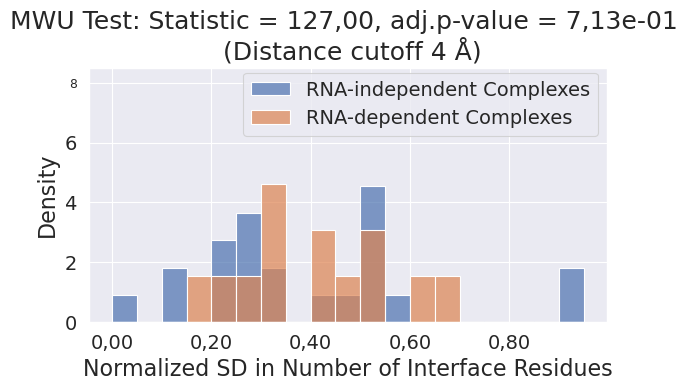

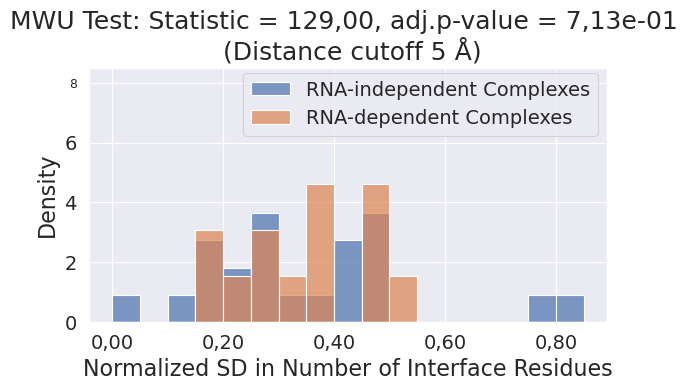

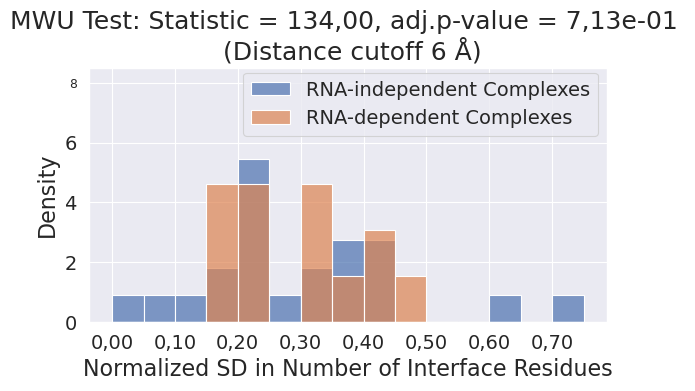

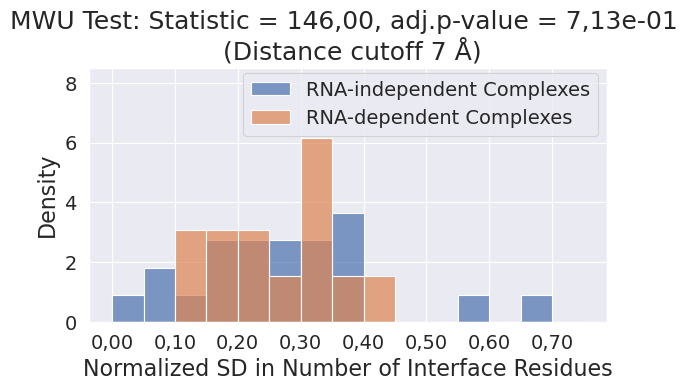

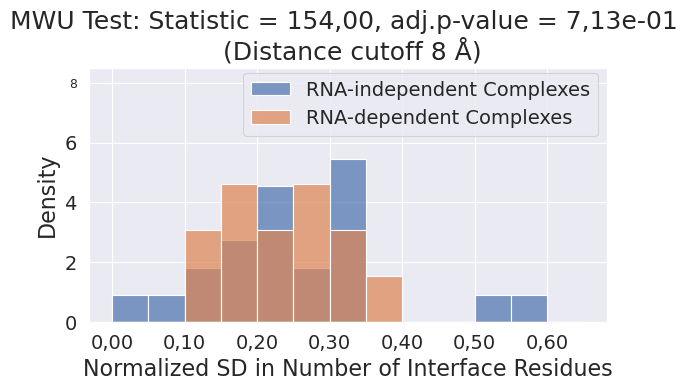

In [26]:
import numpy as np
from scipy.stats import mannwhitneyu
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator

sd_res_cols = [col for col in df_pos.columns if col.startswith("SD")]

for col in sd_res_cols:

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]
    U_stat = row["U_statistic"]

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 0.05
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-independent Complexes",
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-dependent Complexes",
    )

    title = f"MWU Test: Statistic = {U_stat:.2f}, adj.p-value = {p_adj:.2e} \n (Distance cutoff {cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")
    plt.title(title, fontsize=18)

    plt.gca().xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: str(f"{x:.2f}").replace(".", ","))
    )

    plt.xlabel("Normalized SD in Number of Interface Residues", fontsize=16)
    plt.ylabel("Density", fontsize=16)
    plt.xticks(fontsize=14)
  
    plt.gca().yaxis.set_major_locator(MultipleLocator(2))
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, loc="upper right", bbox_to_anchor=(1, 1.02))
    plt.ylim(0,8.5)


    plt.tight_layout()
    plt.savefig(
        f"/mnt/storage/ana01/results/figures/RNase/hist_{col.replace(' ', '_').replace('Å','A')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

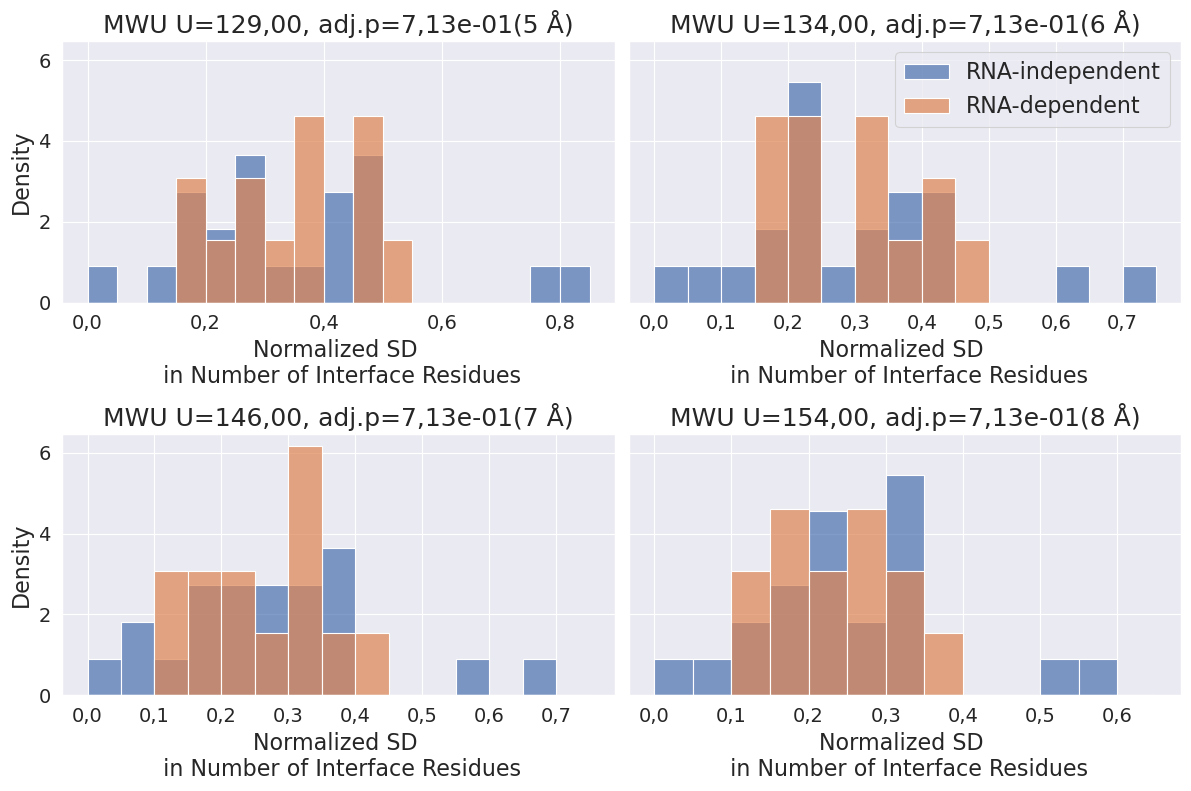

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from matplotlib.ticker import FuncFormatter

sd_res_cols = sorted(
    [col for col in df_pos.columns if col.startswith("SD") and any(k in col for k in ["5", "6", "7", "8"])],
    key=lambda x: float("".join(c for c in x if (c.isdigit() or c == ".")))
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, sd_res_cols):

    row = df_mwu_results[df_mwu_results["Cutoff"] == col].iloc[0]
    p_adj = row["p_adj"]
    U_stat = row["U_statistic"]

    combined = pd.concat([df_pos[col], df_neg[col]])

    bin_width = 0.05
    min_edge = np.floor(combined.min() / bin_width) * bin_width
    max_edge = np.ceil(combined.max() / bin_width) * bin_width
    shared_bins = np.arange(min_edge, max_edge + bin_width, bin_width)

    cutoff_value = "".join([c for c in str(col) if (c.isdigit() or c == ".")])

    sns.histplot(
        df_pos[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-independent",
        ax=ax
    )

    sns.histplot(
        df_neg[col],
        bins=shared_bins,
        stat="density",
        alpha=0.7,
        label="RNA-dependent",
        ax=ax
    )

    title = f"MWU U={U_stat:.2f}, adj.p={p_adj:.2e}({cutoff_value} Å)"
    title = title.replace(".", ",")
    title = title.replace("adj,", "adj.")

    ax.set_title(title, fontsize=18)

    ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
    )
    ax.yaxis.set_major_locator(MultipleLocator(2))

    ax.tick_params(axis='both', labelsize=14)

    ax.set_xlabel("Normalized SD \n in Number of Interface Residues", fontsize=16)

axes[0].set_ylabel("Density", fontsize=16)
axes[2].set_ylabel("Density", fontsize=16)

axes[1].legend(fontsize=16, loc="upper right")

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/figures/RNase/SD_hist_2x2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Plot for Figure 14B

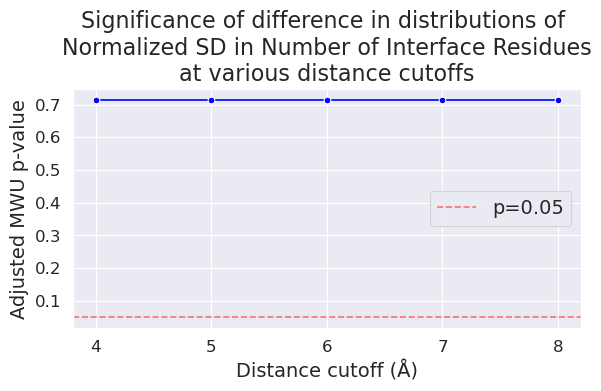

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", context="paper")

df_plot = df_mwu_results.copy()
df_plot['Cutoff_Å'] = df_plot['Cutoff'].str.extract(r'(\d+)').astype(int)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=df_plot,
    x='Cutoff_Å',
    y='p_adj',
    marker='o',
    color='blue'
)

plt.axhline(0.05, linestyle='--', color='red', alpha=0.5, label='p=0.05')

plt.xlabel("Distance cutoff (Å)", fontsize=14)
plt.ylabel("Adjusted MWU p-value", fontsize=14)
plt.title(
    "Significance of difference in distributions of \nNormalized SD in Number of Interface Residues\nat various distance cutoffs",
    fontsize=16
)

plt.xticks(df_plot['Cutoff_Å'], fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

Notebook summary: 

Three additional AFM metrics tested for their ability discern experimental positive and negative proteins in coIP-MS RNase dataset - all insignificant.

* ipLDDT: for all cutoffs
* Average # interface residues (across 5 AF predictions)
* Normalized Variance in # interface residues predicted (across 5 models)